# Modelo predictivo de ventas — Empresa aliada (Vanish y Lysol)

En esta practica construyo un modelo para pronosticar las ventas semanales de dos productos clave, Vanish y Lysol, a partir de las ventas historicas. Uso un enfoque de **series de tiempo (ARIMA)**, siguiendo el flujo que vimos en el curso: pruebo estacionariedad con Dickey-Fuller, elijo el orden con el AIC, valido con metricas de error y genero el pronostico de las proximas semanas.

## Paso 1: Cargar y preparar los datos

Los datos vienen en un **esquema de estrella**: una tabla de hechos con las ventas y varias tablas de dimensiones que la describen. Antes de modelar revise las 5 tablas para entender que aporta cada una y decidir cuales necesito:

| Tabla | Que contiene | La uso? |
|---|---|---|
| **FACT_SALES** | Ventas semanales por item y region (lo que quiero predecir) | **Si** — es la base del modelo |
| **DIM_PRODUCT** | Marca y fabricante de cada item | **Si** — la ocupo para saber que items son Vanish y cuales Lysol |
| **DIM_CALENDAR** | Convierte la semana (texto "34-22") en una fecha real | **Si** — la ocupo para ordenar la serie de tiempo |
| **DIM_CATEGORY** | Traduce el numero de categoria a su nombre | No — filtro por marca, no por categoria |
| **DIM_SEGMENT** | Desglosa los productos en segmentos por atributos | No — agrupo toda la marca junta, sin separar por segmento |

Es decir, para este objetivo (predecir ventas por **marca** a lo largo del **tiempo**) me bastan la tabla de hechos y las dos dimensiones que contestan "de que marca es" (DIM_PRODUCT) y "de cuando es" (DIM_CALENDAR). Las otras dos (categoria y segmento) servirian para cortes de analisis distintos o para enriquecer un modelo de regresion con esas variables, pero no aplican a este modelo de series de tiempo por marca.

Uno entonces la tabla de hechos con el producto (para la marca) y con el calendario (para la fecha).

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

import os
os.chdir("C:/Users/LUIS HERNANDEZ/Desktop/EBAC")

In [18]:
# De las 5 tablas del esquema, cargo las 3 que necesita el modelo: la de hechos (ventas),
# DIM_PRODUCT (para la marca) y DIM_CALENDAR (para la fecha). DIM_CATEGORY y DIM_SEGMENT
# las revise pero no aplican a un modelo de series de tiempo por marca (ver nota de arriba).
fact = pd.read_csv("FACT_SALES_F.csv", dtype={"ITEM_CODE": str, "WEEK": str})
prod = pd.read_excel("DIM_PRODUCT_F.xlsx", dtype={"ITEM": str})
cal  = pd.read_excel("DIM_CALENDAR_F.xlsx")

print("Ventas:", fact.shape, "| Productos:", prod.shape, "| Calendario:", cal.shape)
fact.head()

Ventas: (122002, 6) | Productos: (505, 9) | Calendario: (156, 5)


,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5
1,34-22,7501058715883,0.487,116.519,2.916,TOTAL AUTOS AREA 5
2,34-22,7702626213774,1.391,68.453,5.171,TOTAL AUTOS AREA 5
3,34-22,7501058716422,0.022,1.481,1.833,TOTAL AUTOS AREA 5
4,34-22,7501058784353,2.037,182.839,5.375,TOTAL AUTOS AREA 5


In [19]:
# Las ventas vienen como texto, las paso a numero
fact["TOTAL_VALUE_SALES"] = pd.to_numeric(fact["TOTAL_VALUE_SALES"], errors="coerce")

# Traigo la marca desde la tabla de productos (uniendo por el codigo de item)
fact = fact.merge(prod[["ITEM", "BRAND"]], left_on="ITEM_CODE", right_on="ITEM", how="left")

# Marco Vanish (junto todas sus submarcas: Vanish, Vanish Poder 02, etc.) y Lysol
fact["MARCA"] = fact["BRAND"].str.upper().apply(
    lambda b: "VANISH" if str(b).startswith("VANISH") else ("LYSOL" if b == "LYSOL" else "OTRA"))

# La region SCANNING MEXICO es el total nacional (suma de las 6 areas), la uso para no duplicar
nacional = fact[fact["REGION"].str.contains("SCANNING")]

print("Marcas encontradas:", fact["MARCA"].value_counts().to_dict())

Marcas encontradas: {'OTRA': 90176, 'VANISH': 28377, 'LYSOL': 3449}


In [20]:
# Funcion para armar la serie semanal de ventas (valor) de una marca, ordenada por fecha
def serie_semanal(marca):
    s = nacional[nacional["MARCA"] == marca].groupby("WEEK", as_index=False)["TOTAL_VALUE_SALES"].sum()
    s = s.merge(cal[["WEEK", "DATE"]], on="WEEK", how="left").sort_values("DATE")
    s = s.set_index("DATE")["TOTAL_VALUE_SALES"]
    return s

vanish = serie_semanal("VANISH")
lysol  = serie_semanal("LYSOL")

print("Vanish:", len(vanish), "semanas |", vanish.index.min().date(), "a", vanish.index.max().date())
print("Lysol :", len(lysol), "semanas")
vanish.head()

Vanish: 80 semanas | 2022-01-09 a 2023-07-17
Lysol : 80 semanas


DATE
2022-01-09    14197.682
2022-01-16    13068.150
2022-01-23    11171.567
2022-01-30    11123.781
2022-02-06    11539.607
Name: TOTAL_VALUE_SALES, dtype: float64

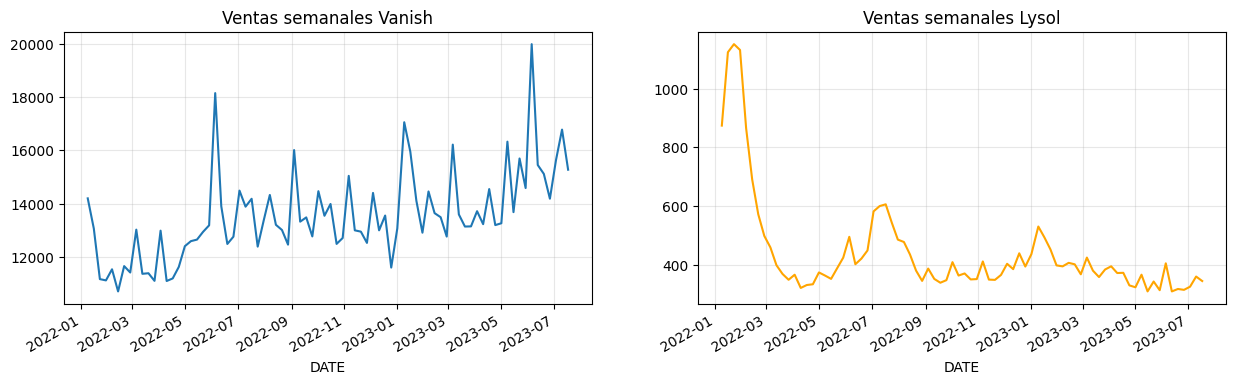

In [21]:
# Grafica de las dos series
fig, ax = plt.subplots(1, 2, figsize=(15,4))
vanish.plot(ax=ax[0], title="Ventas semanales Vanish"); ax[0].grid(alpha=0.3)
lysol.plot(ax=ax[1], title="Ventas semanales Lysol", color="orange"); ax[1].grid(alpha=0.3)
plt.show()

## Paso 2: Selección de la técnica de modelado

Los datos son **ventas semanales a lo largo del tiempo**, asi que lo natural es un modelo de **series de tiempo** y no una regresion (no tengo variables explicativas como precio o promociones, solo el historico de ventas). 

Elijo **ARIMA** porque es justo lo que trabajamos en el curso: determino el grado de diferenciacion `d` con la prueba de Dickey-Fuller y elijo `p` y `q` con el AIC. 

Nota sobre la estacionalidad: en Vanish se alcanza a ver un patron que se repite cada año, pero como solo tengo alrededor de 1.5 años de datos (80 semanas), no llego a dos ciclos completos, que es lo minimo para estimar bien un modelo estacional tipo SARIMA. Por eso me quedo con ARIMA, que es mas estable con esta cantidad de datos.

## Paso 3: División en entrenamiento y prueba

Como es una serie de tiempo, la division es **temporal** (no aleatoria): entreno con la parte mas vieja y pruebo con la mas reciente. Uso 80% para entrenar y 20% para probar.

In [22]:
len_train = int(len(vanish) * 0.8)

train = vanish[:len_train]
test = vanish[len_train:]

print("Entrenamiento:", len(train), "semanas | Prueba:", len(test), "semanas")

Entrenamiento: 64 semanas | Prueba: 16 semanas


## Paso 4: Construcción y entrenamiento del modelo

Primero determino `d` con Dickey-Fuller (cuantas diferencias necesito para que la serie sea estacionaria), y luego busco los mejores `p` y `q` por AIC.

In [23]:
# Prueba de Dickey-Fuller: cuento cuantas diferencias hacen falta para volverla estacionaria
# H0: la serie NO es estacionaria
serie_actual = train.copy()
d = 0
pval = adfuller(serie_actual)[1]
print("Diferencia", d, "= valor p:", round(pval, 4))

while pval > 0.05:
    serie_actual = serie_actual.diff().dropna()
    d = d + 1
    pval = adfuller(serie_actual)[1]
    print("Diferencia", d, "= valor p:", round(pval, 4))

print("\nGrado de diferenciacion elegido: d =", d)

Diferencia 0 = valor p: 0.2104
Diferencia 1 = valor p: 0.019

Grado de diferenciacion elegido: d = 1


In [24]:
# Busco la mejor combinacion de (p, d, q) por el menor AIC
mejor_aic = np.inf
mejor_orden = None

for p in range(0, 4):
    for q in range(0, 4):
        try:
            modelo = ARIMA(train, order=(p, d, q)).fit()
            print("ARIMA", (p, d, q), "-> AIC:", round(modelo.aic, 2))
            if modelo.aic < mejor_aic:
                mejor_aic = modelo.aic
                mejor_orden = (p, d, q)
        except:
            pass

print("\nMejor modelo por AIC:", mejor_orden, "con AIC", round(mejor_aic, 2))

ARIMA (0, 1, 0) -> AIC: 1112.68
ARIMA (0, 1, 1) -> AIC: 1093.07
ARIMA (0, 1, 2) -> AIC: 1092.9
ARIMA (0, 1, 3) -> AIC: 1093.63
ARIMA (1, 1, 0) -> AIC: 1107.38
ARIMA (1, 1, 1) -> AIC: 1092.71
ARIMA (1, 1, 2) -> AIC: 1093.83
ARIMA (1, 1, 3) -> AIC: 1094.0
ARIMA (2, 1, 0) -> AIC: 1102.91
ARIMA (2, 1, 1) -> AIC: 1091.99
ARIMA (2, 1, 2) -> AIC: 1092.67
ARIMA (2, 1, 3) -> AIC: 1093.89
ARIMA (3, 1, 0) -> AIC: 1089.4
ARIMA (3, 1, 1) -> AIC: 1090.12
ARIMA (3, 1, 2) -> AIC: 1091.34
ARIMA (3, 1, 3) -> AIC: 1093.62

Mejor modelo por AIC: (3, 1, 0) con AIC 1089.4


In [25]:
# Entreno el mejor modelo
modelo = ARIMA(train, order=mejor_orden).fit()
print(modelo.summary())

                               SARIMAX Results                                
Dep. Variable:      TOTAL_VALUE_SALES   No. Observations:                   64
Model:                 ARIMA(3, 1, 0)   Log Likelihood                -540.701
Date:                Sat, 01 Aug 2026   AIC                           1089.402
Time:                        19:26:04   BIC                           1097.975
Sample:                             0   HQIC                          1092.774
                                 - 64                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5326      0.106     -5.012      0.000      -0.741      -0.324
ar.L2         -0.4631      0.139     -3.331      0.001      -0.736      -0.191
ar.L3         -0.3738      0.080     -4.667      0.0

## Paso 5: Validación del modelo

Pronostico el periodo de prueba y comparo contra las ventas reales con MSE, MAE y MAPE.

In [26]:
# Pronostico sobre el periodo de prueba
pred = modelo.forecast(len(test))
pred.index = test.index

# Metricas de error
mse = mean_squared_error(test, pred)
mae = mean_absolute_error(test, pred)
mape = np.mean(np.abs((test.values - pred.values) / test.values)) * 100

print("MSE :", round(mse, 2))
print("MAE :", round(mae, 2))
print("MAPE:", round(mape, 2), "%")

MSE : 4548715.35
MAE : 1556.34
MAPE: 9.55 %


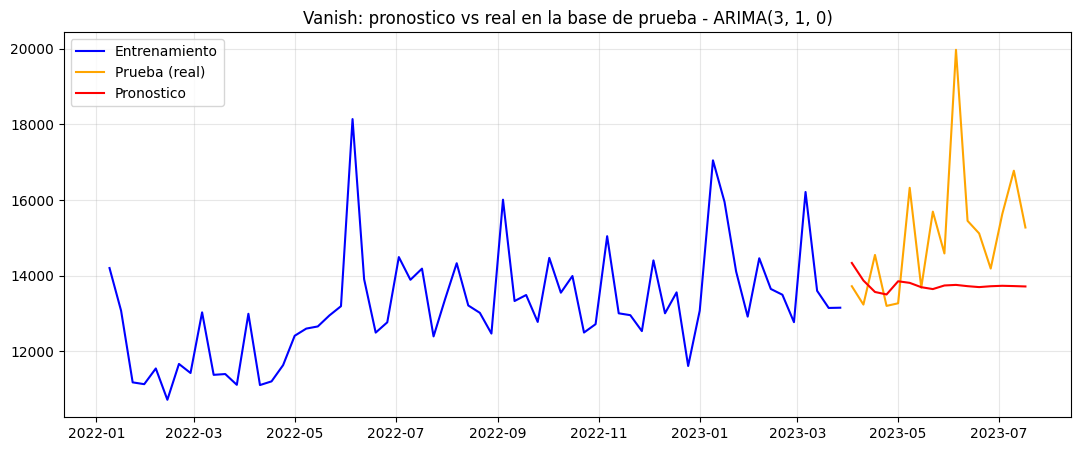

In [27]:
# Grafica de las predicciones contra los datos reales
plt.figure(figsize=(13,5))
plt.plot(train, label="Entrenamiento", color="blue")
plt.plot(test, label="Prueba (real)", color="orange")
plt.plot(pred, label="Pronostico", color="red")
plt.title("Vanish: pronostico vs real en la base de prueba - ARIMA" + str(mejor_orden))
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Paso 6: Ajuste y optimización

Para intentar mejorar el ajuste pruebo transformar las ventas con logaritmo (suele estabilizar la varianza en datos de ventas) y vuelvo a buscar el mejor orden. Comparo el MAPE contra el modelo original y me quedo con el mejor.

In [28]:
# Modelo alternativo: sobre el logaritmo de las ventas
train_log = np.log(train)

# mismo procedimiento de d por Dickey-Fuller sobre la serie en log
s2 = train_log.copy(); d2 = 0; p2 = adfuller(s2)[1]
while p2 > 0.05:
    s2 = s2.diff().dropna(); d2 += 1; p2 = adfuller(s2)[1]

mejor_aic2 = np.inf; mejor_orden2 = None
for p in range(0, 4):
    for q in range(0, 4):
        try:
            m = ARIMA(train_log, order=(p, d2, q)).fit()
            if m.aic < mejor_aic2:
                mejor_aic2 = m.aic; mejor_orden2 = (p, d2, q)
        except:
            pass

modelo_log = ARIMA(train_log, order=mejor_orden2).fit()
pred_log = np.exp(modelo_log.forecast(len(test)))   # regreso a la escala original
pred_log.index = test.index

mape_log = np.mean(np.abs((test.values - pred_log.values) / test.values)) * 100
print("Modelo con log -> orden:", mejor_orden2, "| MAPE:", round(mape_log, 2), "%")
print("Modelo original ->", mejor_orden, "| MAPE:", round(mape, 2), "%")

Modelo con log -> orden: (2, 1, 3) | MAPE: 8.99 %
Modelo original -> (3, 1, 0) | MAPE: 9.55 %


El modelo con logaritmo dio un MAPE de **8.99%** y el original **9.55%**, practicamente lo mismo (media punto de diferencia). Como la mejora es minima, me quedo con el modelo **original ARIMA(3,1,0)** porque es mas simple y pronostica directo en pesos, sin tener que regresar de la escala logaritmica. Aun asi documento que la transformacion se probo, que era el punto del paso de optimizacion.

## Paso 7: Predicciones futuras

Reentreno el mejor modelo con **toda** la historia de Vanish y pronostico las proximas 12 semanas (aprox. 3 meses), con su intervalo de confianza.

In [29]:
# Reentreno con toda la serie y pronostico 12 semanas hacia adelante
modelo_final = ARIMA(vanish, order=mejor_orden).fit()

n_fut = 12
futuro = modelo_final.get_forecast(n_fut)
pred_fut = futuro.predicted_mean
conf_fut = futuro.conf_int(alpha=0.05)

# fechas futuras (semanales)
fechas_fut = pd.date_range(vanish.index[-1] + pd.Timedelta(weeks=1), periods=n_fut, freq="W")
pred_fut.index = fechas_fut
conf_fut.index = fechas_fut
conf_fut.columns = ["inferior", "superior"]

tabla_fut = pd.DataFrame({"semana": fechas_fut,
                          "pronostico": pred_fut.values.round(0),
                          "inf_95%": conf_fut["inferior"].values.round(0),
                          "sup_95%": conf_fut["superior"].values.round(0)})
tabla_fut

,semana,pronostico,inf_95%,sup_95%
0,2023-07-30,15044.0,12404.0,17684.0
1,2023-08-06,15422.0,12556.0,18288.0
2,2023-08-13,15897.0,12928.0,18866.0
3,2023-08-20,15537.0,12498.0,18575.0
4,2023-08-27,15377.0,12000.0,18753.0
5,2023-09-03,15450.0,11871.0,19030.0
6,2023-09-10,15623.0,11901.0,19345.0
7,2023-09-17,15552.0,11716.0,19387.0
8,2023-09-24,15484.0,11475.0,19494.0
9,2023-10-01,15488.0,11321.0,19656.0


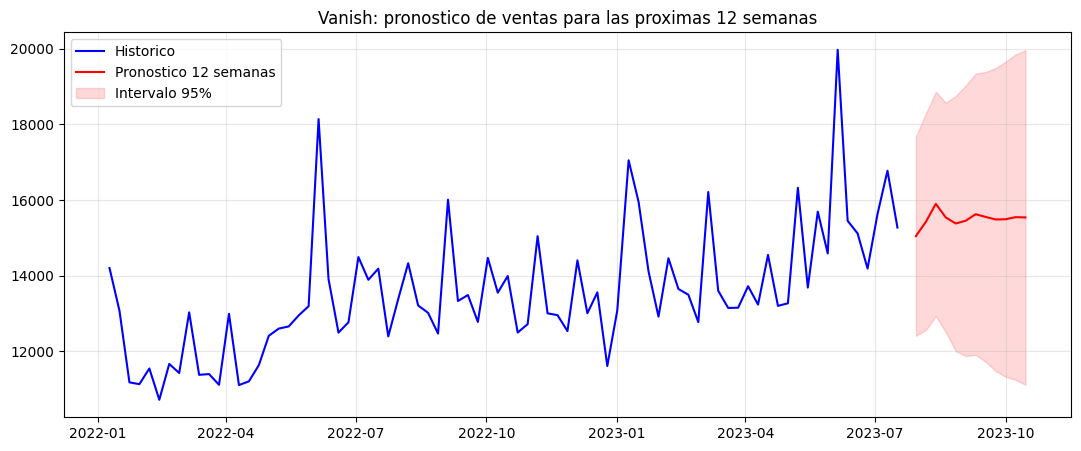

In [30]:
# Grafica del pronostico futuro
plt.figure(figsize=(13,5))
plt.plot(vanish, label="Historico", color="blue")
plt.plot(pred_fut, label="Pronostico 12 semanas", color="red")
plt.fill_between(fechas_fut, conf_fut["inferior"], conf_fut["superior"], color="red", alpha=0.15, label="Intervalo 95%")
plt.title("Vanish: pronostico de ventas para las proximas 12 semanas")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Paso 8: Aplicación a Lysol y documentación final

Aplico exactamente el mismo procedimiento a Lysol (Dickey-Fuller para d, AIC para p y q, validacion y pronostico).

In [31]:
# --- Mismo procedimiento para Lysol ---
len_train_l = int(len(lysol) * 0.8)
train_l = lysol[:len_train_l]
test_l = lysol[len_train_l:]

# d por Dickey-Fuller
sl = train_l.copy(); dl = 0; pl = adfuller(sl)[1]
while pl > 0.05:
    sl = sl.diff().dropna(); dl += 1; pl = adfuller(sl)[1]

# mejor (p,d,q) por AIC
aic_l = np.inf; orden_l = None
for p in range(0, 4):
    for q in range(0, 4):
        try:
            m = ARIMA(train_l, order=(p, dl, q)).fit()
            if m.aic < aic_l:
                aic_l = m.aic; orden_l = (p, dl, q)
        except:
            pass

modelo_l = ARIMA(train_l, order=orden_l).fit()
pred_l = modelo_l.forecast(len(test_l)); pred_l.index = test_l.index
mape_l = np.mean(np.abs((test_l.values - pred_l.values) / test_l.values)) * 100

print("Lysol -> mejor modelo:", orden_l, "| d =", dl, "| MAPE:", round(mape_l, 2), "%")

Lysol -> mejor modelo: (0, 1, 2) | d = 1 | MAPE: 25.86 %


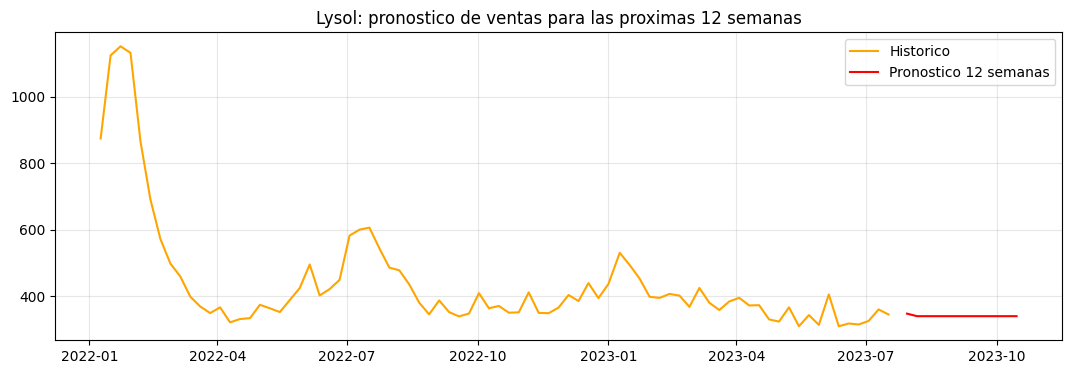

In [32]:
# Pronostico futuro de Lysol (12 semanas) con toda su historia
modelo_l_final = ARIMA(lysol, order=orden_l).fit()
fut_l = modelo_l_final.forecast(12)
fut_l.index = pd.date_range(lysol.index[-1] + pd.Timedelta(weeks=1), periods=12, freq="W")

plt.figure(figsize=(13,4))
plt.plot(lysol, label="Historico", color="orange")
plt.plot(fut_l, label="Pronostico 12 semanas", color="red")
plt.title("Lysol: pronostico de ventas para las proximas 12 semanas")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Documentación y conclusiones

**Tecnica elegida y por que.** Los datos son ventas semanales en el tiempo, sin variables explicativas extra, asi que use series de tiempo (ARIMA) en lugar de regresion. El grado de diferenciacion `d` lo decide la prueba de Dickey-Fuller (Vanish salio no estacionaria con p=0.21 y con una diferencia quedo estacionaria, asi que d=1) y los ordenes `p` y `q` los elige el AIC. No use SARIMA porque con ~1.5 años de datos no hay dos ciclos anuales completos para estimar bien la parte estacional.

**Modelo y validacion.** Para Vanish el mejor modelo por AIC fue **ARIMA(3,1,0)**, con un **MAPE de 9.55%** en la base de prueba, es decir que en promedio el pronostico se equivoca alrededor de un 10% respecto a la venta real. Es un ajuste bueno para ventas semanales, que traen bastante ruido.

**Ajuste / optimizacion.** Probe una transformacion logaritmica para ver si mejoraba la precision: dio 8.99% de MAPE, apenas medio punto mejor que el original. Como la diferencia es minima, me quede con el modelo original por ser mas simple y directo de interpretar.

**Predicciones y recomendaciones.**
- **Vanish** es una marca grande y estable (~13,500 por semana) con ligera tendencia al alza; su pronostico a 12 semanas es confiable en el corto plazo, con el intervalo abriendose conforme se aleja.
- **Lysol** es una marca chica y en **declive** (bajo de ~1,100 a ~330 por semana). Su mejor modelo fue ARIMA(0,1,2) pero con un MAPE de 25.86%, bastante mas alto: la serie es chica y ruidosa, asi que su pronostico hay que tomarlo con reserva y conviene revisar que esta pasando comercialmente con la marca.
- **Recomendacion practica:** usar estos pronosticos para planear inventario/produccion de las proximas semanas, actualizando el modelo cada vez que lleguen datos nuevos. Para Lysol, investigar la caida antes de proyectar a mas largo plazo.

**Nota sobre el alcance.** Estos modelos usan solo el historico de ventas. Si se quisiera mas precision, el siguiente paso seria incorporar variables externas (precio, promociones, distribucion) en un modelo tipo regresion o ARIMAX.